<a href="https://colab.research.google.com/github/hkubramese/ars-coregulation-cancer/blob/main/notebooks/02_pancancer_coexpression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ARS Co-regulation in Cancer — Step 2: Pan-cancer Co-expression
## Is the ARS module present across cancer types, and is its link to ATF4 specific?

**Project:** ARS co-regulation in cancer (bioRxiv preprint + GitHub repository)
**Notebook:** `02_pancancer_coexpression.ipynb` — Version 1.0
**Builds on:** `01_feasibility_pilot.ipynb` (TCGA-LUAD, decision A)

### WHERE WE ARE
The Step 1 pilot in TCGA-LUAD (516 primary tumours) showed that:
* cytoplasmic ARS genes are co-expressed far above random expectation (median ρ = 0.358 vs. random 95th percentile 0.182),
* about 73% of this signal remains after proliferation adjustment (ρ = 0.261),
* the cytoplasmic ARS module is more strongly linked to an ATF4 signature (ρ = 0.311) than the mitochondrial module (ρ = 0.131).

### GOAL OF THIS NOTEBOOK
Step 1 had three weaknesses. This notebook addresses each of them:

| Weakness in Step 1 | What Step 2 does |
| --- | --- |
| One cancer type only | Repeats the analysis in all 33 TCGA cancer types |
| Provisional marker lists | Uses **published** gene sets: MSigDB Hallmark (proliferation) and TRRUST (literature-curated ATF4 targets) |
| No biological control | Compares ARS genes with **ribosomal protein genes**, another translation module. If ARS genes are linked to ATF4 *beyond* the general translation programme, the ATF4 link should be stronger for ARS than for ribosomal proteins |

A fourth improvement: **tumour purity**. A tumour sample also contains normal cells (stroma, immune cells). Differences in this mixture can create correlations between genes. We adjust for published ABSOLUTE purity estimates from the TCGA PanCanAtlas.

Keep this distinction in mind:

```text
pan-cancer correlation     = a robust pattern
regulatory mechanism       = a claim that needs chromatin evidence (Step 5) and validation (Step 6)
```

### HOW TO WORK WITH THIS NOTEBOOK
1. Save a copy in your own Google Drive: **File > Save a copy in Drive**.
2. Run the cells **in order**, one by one.
3. Step 12 analyses 33 cancer types and takes the longest (roughly 30–90 minutes, depending on Colab). It saves each cancer type's result as soon as it is finished. **If Colab disconnects, re-run the notebook from the top: finished cancer types are skipped automatically.**

### Pre-registered questions
We write the questions and the decision rule **before** seeing the results (Step 17), exactly as in Step 1.

1. In how many cancer types is the cytoplasmic ARS module co-expressed above random expectation **after** proliferation and purity adjustment?
2. Is the ATF4 link stronger for cytoplasmic ARS genes than for mitochondrial ARS genes?
3. Is the ATF4 link stronger for cytoplasmic ARS genes than for ribosomal protein genes (specificity test)?

# PART I: Working environment

## 1. Google Drive connection
We read the Step 1 input manifest from Drive and copy the Step 2 results back to Drive at the end.

In [1]:
# 1. COLAB GUIDE: Connect Google Drive to the Colab session.
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 2. Analysis root and sub-folders
Same structure as Step 1. A new folder, `results/per_cancer/`, stores one small result file per cancer type. These files make the long loop in Step 12 **resumable**.

| Folder | Content |
| --- | --- |
| `data/` | Temporary downloads (each expression matrix is deleted after it is analysed) |
| `results/` | Result tables (TSV) |
| `results/per_cancer/` | One result row per cancer type (checkpoint files) |
| `figures/` | Plots |
| `logs/` | Versions, gene set provenance, input manifest |

In [2]:
# 2. PYTHON GUIDE: 'Path' joins folder and file names safely with the '/' operator.
from pathlib import Path
import shutil

ROOT = Path("/content/ARS_step2_pancancer")
DATA_DIR, RES_DIR = ROOT/"data", ROOT/"results"
FIG_DIR, LOG_DIR = ROOT/"figures", ROOT/"logs"
PER_CANCER_DIR = RES_DIR/"per_cancer"

for folder in [ROOT, DATA_DIR, RES_DIR, PER_CANCER_DIR, FIG_DIR, LOG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Analysis root:", ROOT)

Analysis root: /content/ARS_step2_pancancer


## 3. Python packages and their versions
New in Step 2:
* **gseapy** — downloads published gene set libraries from the Enrichr service.
* **scipy** — statistical tests (pre-installed in Colab).

⚙️ **Tool parameter:** `pip -q install` installs quietly.

In [3]:
# 3. COLAB AND TERMINAL GUIDE: '!' sends the command to the Linux terminal. In a real terminal there is no '!'.
!pip -q install gseapy

import sys, re, subprocess
import numpy as np, pandas as pd, matplotlib, scipy, gseapy as gp
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

versions = (f"python {sys.version.split()[0]}\nnumpy {np.__version__}\npandas {pd.__version__}\n"
            f"matplotlib {matplotlib.__version__}\nscipy {scipy.__version__}\ngseapy {gp.__version__}\n")
print(versions)
(LOG_DIR/"python_versions.txt").write_text(versions)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.7/689.7 kB 12.5 MB/s eta 0:00:00
python 3.13.16
numpy 2.1.3
pandas 2.2.3
matplotlib 3.10.0
scipy 1.16.3
gseapy 1.3.1



84

# PART II: Gene sets

## 4. ARS gene list
Identical to Step 1: 20 cytoplasmic and 17 mitochondrial ARS genes, with a fallback to the old HGNC symbols (`AARS` instead of `AARS1`, etc.).

In [4]:
# 4. GENE SETS: ARS genes (current HGNC symbols)
ARS_CYTO = ["AARS1", "CARS1", "DARS1", "EPRS1", "FARSA", "FARSB", "GARS1", "HARS1", "IARS1", "KARS1",
            "LARS1", "MARS1", "NARS1", "QARS1", "RARS1", "SARS1", "TARS1", "VARS1", "WARS1", "YARS1"]
ARS_MITO = ["AARS2", "CARS2", "DARS2", "EARS2", "FARS2", "HARS2", "IARS2", "LARS2", "MARS2",
            "NARS2", "PARS2", "RARS2", "SARS2", "TARS2", "VARS2", "WARS2", "YARS2"]
OLD_SYMBOL = {g: g[:-1] for g in ARS_CYTO if g.endswith("1")}
ALL_ARS = set(ARS_CYTO + ARS_MITO + list(OLD_SYMBOL.values()))

assert len(ARS_CYTO) == 20 and len(ARS_MITO) == 17
print(f"Cytoplasmic ARS: {len(ARS_CYTO)} genes | Mitochondrial ARS: {len(ARS_MITO)} genes")

Cytoplasmic ARS: 20 genes | Mitochondrial ARS: 17 genes


## 5. Published control signatures (replacing the Step 1 marker lists)

| Signature | Source | Enrichr library | Role |
| --- | --- | --- | --- |
| Proliferation | MSigDB Hallmark **G2-M Checkpoint** (Liberzon et al., Cell Systems 2015) | `MSigDB_Hallmark_2020` | Covariate: removes the cell division signal |
| ATF4 activity (main) | **TRRUST v2** literature-curated ATF4 target genes (Han et al., Nucleic Acids Research 2018) | `TRRUST_Transcription_Factors_2019` | ATF4 score |
| ATF4 activity (sensitivity) | MSigDB Hallmark **Unfolded Protein Response** | `MSigDB_Hallmark_2020` | Second, broader stress-response score to check robustness |

**Circularity rule (as in Step 1):** every ARS gene is removed from every control signature. Otherwise "ARS correlates with ATF4" would be partly true by construction.

All gene lists are saved to `logs/gene_sets_used.tsv`, so the exact genes behind every number are documented.

In [5]:
# 5. PUBLISHED GENE SETS: downloaded from Enrichr with gseapy (returns a dictionary: term -> list of genes)
hallmark = gp.get_library(name="MSigDB_Hallmark_2020", organism="Human")
trrust = gp.get_library(name="TRRUST_Transcription_Factors_2019", organism="Human")

def pick_term(library, must_contain, label):
    hits = [t for t in library if all(w.lower() in t.lower() for w in must_contain)]
    assert hits, f"No term containing {must_contain} found for {label}. Inspect: list(library)[:20]"
    print(f"{label:22s} -> using term: '{hits[0]}'" + (f" (other matches: {hits[1:]})" if len(hits) > 1 else ""))
    return hits[0]

g2m_term  = pick_term(hallmark, ["G2-M"], "Proliferation")
upr_term  = pick_term(hallmark, ["Unfolded Protein"], "ATF4 (sensitivity)")
atf4_term = pick_term({t: v for t, v in trrust.items() if t.split()[0].upper() == "ATF4"}, ["human"], "ATF4 (main, TRRUST)")

SIGNATURES = {
    "Proliferation": sorted(set(hallmark[g2m_term]) - ALL_ARS),
    "ATF4_TRRUST":   sorted(set(trrust[atf4_term]) - ALL_ARS),
    "ATF4_UPR":      sorted(set(hallmark[upr_term]) - ALL_ARS),
}
for name, genes in SIGNATURES.items():
    print(f"{name:14s} {len(genes):3d} genes (ARS genes removed)")
assert len(SIGNATURES["ATF4_TRRUST"]) >= 5, "Too few TRRUST ATF4 targets. Check the library."

pd.DataFrame([(k, g) for k, v in SIGNATURES.items() for g in v], columns=["signature", "gene"]) \
  .to_csv(LOG_DIR/"gene_sets_used.tsv", sep="\t", index=False)

Proliferation          -> using term: 'G2-M Checkpoint'
ATF4 (sensitivity)     -> using term: 'Unfolded Protein Response'
ATF4 (main, TRRUST)    -> using term: 'ATF4 human'
Proliferation  200 genes (ARS genes removed)
ATF4_TRRUST     35 genes (ARS genes removed)
ATF4_UPR       111 genes (ARS genes removed)


## 6. Biological control modules: ribosomal proteins
Ribosomal protein genes are the classic "translation machinery" module. They are defined from the gene symbols:

* **RP (cytosolic ribosome):** `RPL…` and `RPS…` genes (e.g. `RPL3`, `RPS6`, `RPLP0`, `RPSA`). Kinases such as `RPS6KA1` and pseudogenes such as `RPL13AP5` are excluded by the pattern.
* **MRP (mitochondrial ribosome):** `MRPL…` and `MRPS…` genes — the natural comparison for mitochondrial ARS genes.

The patterns are applied in Step 9, after the gene symbol table has been loaded.

In [6]:
# 6. REGULAR EXPRESSIONS for ribosomal protein genes
#    ^ = start of the name, $ = end of the name, \d+ = one or more digits, [A-Z]? = optional single letter
RP_PATTERN  = re.compile(r"^(RP[LS]\d+[A-Z]?|RPLP[0-2]|RPSA)$")
MRP_PATTERN = re.compile(r"^MRP[LS]\d+$")

tests = ["RPL3", "RPS6", "RPLP0", "RPSA", "RPS4X", "RPS6KA1", "RPL13AP5", "MRPL12", "MRPS2"]
print({g: ("RP" if RP_PATTERN.match(g) else "MRP" if MRP_PATTERN.match(g) else "-") for g in tests})

{'RPL3': 'RP', 'RPS6': 'RP', 'RPLP0': 'RP', 'RPSA': 'RP', 'RPS4X': 'RP', 'RPS6KA1': '-', 'RPL13AP5': '-', 'MRPL12': 'MRP', 'MRPS2': 'MRP'}


# PART III: Inputs

## 7. Expression data links (re-using the Step 1 link)
In Step 1 you copied the TCGA-LUAD **STAR - TPM** link from UCSC Xena. The other 32 cancer types follow exactly the same naming pattern on the Xena GDC hub; only the project code changes (`TCGA-LUAD` → `TCGA-BRCA`, `TCGA-COAD`, ...).

This cell reads your Step 1 input manifest from Drive and builds the 33 links from it. Nothing has to be pasted, as long as the Step 1 outputs are in `My Drive/ARS_project/01_feasibility_pilot/`.

In [7]:
# 7. LINKS: read the Step 1 manifest and build one link per TCGA project
STEP1_MANIFEST = Path("/content/drive/MyDrive/ARS_project/01_feasibility_pilot/logs/input_manifest.tsv")
assert STEP1_MANIFEST.exists(), f"Step 1 manifest not found: {STEP1_MANIFEST}"

step1 = pd.read_csv(STEP1_MANIFEST, sep="\t").set_index("ROLE")
LUAD_TPM_URL = step1.loc["expression_tpm", "URL"]
PROBEMAP_URL = step1.loc["id_gene_mapping", "URL"]
assert "TCGA-LUAD" in LUAD_TPM_URL, "The Step 1 TPM link does not contain 'TCGA-LUAD'. Check the manifest."

TCGA_PROJECTS = ["ACC", "BLCA", "BRCA", "CESC", "CHOL", "COAD", "DLBC", "ESCA", "GBM", "HNSC", "KICH",
                 "KIRC", "KIRP", "LAML", "LGG", "LIHC", "LUAD", "LUSC", "MESO", "OV", "PAAD", "PCPG",
                 "PRAD", "READ", "SARC", "SKCM", "STAD", "TGCT", "THCA", "THYM", "UCEC", "UCS", "UVM"]
TPM_URLS = {p: LUAD_TPM_URL.replace("TCGA-LUAD", f"TCGA-{p}") for p in TCGA_PROJECTS}

assert len(TPM_URLS) == 33
print("Example links:")
for p in ["LUAD", "BRCA", "UVM"]:
    print(f"  {p}: {TPM_URLS[p]}")

Example links:
  LUAD: https://gdc-hub.s3.us-east-1.amazonaws.com/download/TCGA-LUAD.star_tpm.tsv.gz
  BRCA: https://gdc-hub.s3.us-east-1.amazonaws.com/download/TCGA-BRCA.star_tpm.tsv.gz
  UVM: https://gdc-hub.s3.us-east-1.amazonaws.com/download/TCGA-UVM.star_tpm.tsv.gz


## 8. Tumour purity (TCGA PanCanAtlas, ABSOLUTE)
The PanCanAtlas consortium estimated the fraction of cancer cells in each TCGA sample with the ABSOLUTE algorithm. The file is open access on the GDC **PanCanAtlas Publications** page (file name `TCGA_mastercalls.abs_tables_JSedit.fixed.txt`).

* The `array` column holds a 15-character sample barcode (e.g. `TCGA-05-4244-01`).
* The `purity` column holds the estimated cancer cell fraction (0–1).

Some samples have no estimate. In those cancer types the analysis is adjusted for proliferation only, and this is recorded in the results (`purity_used`).

In [8]:
# 8. PURITY FILE: download from the GDC PanCanAtlas page
PURITY_URL = "https://api.gdc.cancer.gov/data/4f277128-f793-4354-a13d-30cc7fe9f6b5"
PURITY_FILE = DATA_DIR/"TCGA_mastercalls.abs_tables_JSedit.fixed.txt"

!wget -q --tries=3 -O "{PURITY_FILE}" "{PURITY_URL}"
assert PURITY_FILE.exists() and PURITY_FILE.stat().st_size > 0, "Purity file could not be downloaded."

purity_table = pd.read_csv(PURITY_FILE, sep="\t")
print("Columns:", list(purity_table.columns))
id_column = "array" if "array" in purity_table.columns else purity_table.columns[0]
PURITY = purity_table.dropna(subset=["purity"]).set_index(purity_table.dropna(subset=["purity"])[id_column].str[:15])["purity"]
PURITY = PURITY[~PURITY.index.duplicated(keep="first")]
print(f"Samples with a purity estimate: {len(PURITY)} | range {PURITY.min():.2f}–{PURITY.max():.2f}")

Columns: ['array', 'sample', 'call status', 'purity', 'ploidy', 'Genome doublings', 'Coverage for 80% power', 'Cancer DNA fraction', 'Subclonal genome fraction', 'solution']
Samples with a purity estimate: 10642 | range 0.08–1.00


## 9. ID → gene symbol mapping
The same ID/Gene Mapping file as in Step 1 (GENCODE v36 annotation, shared by all GDC hub expression matrices).

In [9]:
# 9. PROBEMAP: Ensembl ID -> gene symbol
PROBEMAP_FILE = DATA_DIR/"probemap.tsv"
!wget -q --tries=3 -O "{PROBEMAP_FILE}" "{PROBEMAP_URL}"

probemap = pd.read_csv(PROBEMAP_FILE, sep="\t")
ID2GENE = dict(zip(probemap.iloc[:, 0], probemap.iloc[:, 1]))
all_symbols = set(probemap.iloc[:, 1].astype(str))

RP_GENES  = sorted(g for g in all_symbols if RP_PATTERN.match(g))
MRP_GENES = sorted(g for g in all_symbols if MRP_PATTERN.match(g))
print(f"Mapping entries: {len(ID2GENE)} | RP genes: {len(RP_GENES)} | MRP genes: {len(MRP_GENES)}")
assert len(RP_GENES) >= 60 and len(MRP_GENES) >= 60, "Unexpected number of ribosomal genes. Check the probemap."

Mapping entries: 60660 | RP genes: 83 | MRP genes: 75


### 9A. Input manifest
All external inputs of Step 2 are recorded in one table.

In [10]:
# 9A. INPUT MANIFEST
manifest = pd.DataFrame(
    [("expression_tpm", p, u) for p, u in TPM_URLS.items()] +
    [("id_gene_mapping", "all", PROBEMAP_URL), ("tumour_purity_absolute", "all", PURITY_URL),
     ("gene_sets", "MSigDB_Hallmark_2020", g2m_term + " | " + upr_term),
     ("gene_sets", "TRRUST_Transcription_Factors_2019", atf4_term)],
    columns=["ROLE", "PROJECT", "SOURCE"])
manifest.to_csv(LOG_DIR/"input_manifest.tsv", sep="\t", index=False)
!sha256sum "{PURITY_FILE}" "{PROBEMAP_FILE}" | tee "{LOG_DIR/'input.sha256.txt'}"

f430a975433d82e0098d7405619d4f12a0c765fcd97e7d63cc9b1de7f2d763cd  /content/ARS_step2_pancancer/data/TCGA_mastercalls.abs_tables_JSedit.fixed.txt
f027752d663b1da74f4113998bf008e6ebecfa3732607513e027bb6eb1f635b5  /content/ARS_step2_pancancer/data/probemap.tsv


# PART IV: The analysis function

## 10. One function, applied to every cancer type
Instead of copying the Step 1 code 33 times, we write it **once** as a function: `analyse_cancer("LUAD")` runs the complete analysis for one project and returns one row of results.

**What the function does (same logic as Step 1, plus the new controls):**
1. Downloads the STAR - TPM matrix, maps IDs to symbols, keeps primary tumours (`01`; for LAML, primary blood `03`), one per patient.
2. Builds module scores (mean z-score): cytoplasmic ARS, mitochondrial ARS, RP, MRP, proliferation, ATF4 (TRRUST), ATF4 (UPR).
3. **Covariates:** proliferation score, and purity if at least `MIN_N` tumours have an estimate.
4. **Question 1:** median pairwise Spearman ρ of cytoplasmic ARS genes, before and after covariate adjustment, against 1,000 expression-matched random gene sets.
5. **Questions 2 and 3:** Spearman ρ between the ATF4 score and each module score after covariate adjustment. A final test also removes the RP module score: *is there an ATF4 link left that general translation cannot explain?*
6. Saves the row to `results/per_cancer/<PROJECT>.tsv` and deletes the downloaded matrix to free disk space.

`MIN_N = 50`: cancer types with fewer primary tumours are skipped and listed in the results. This threshold is fixed **before** the analysis.

In [11]:
# 10A. SETTINGS (fixed before the analysis)
MIN_N = 50          # minimum number of primary tumours per cancer type
N_PERM = 1000       # random gene sets per null distribution
SEED = 2026         # fixed seed: the same random sets every time
TUMOUR_CODES = {"01"}            # primary solid tumour
TUMOUR_CODES_LAML = {"03"}       # primary blood-derived cancer (leukaemia)

In [12]:
# 10B. HELPER FUNCTIONS (each one does a single, small job)

def find_genes(genes, index):
    # current HGNC symbol first, old symbol second
    out = []
    for g in genes:
        if g in index: out.append(g)
        elif OLD_SYMBOL.get(g) in index: out.append(OLD_SYMBOL[g])
    return out

def zscore_mean(data, genes):
    sub = data.loc[genes]
    z = sub.sub(sub.mean(axis=1), axis=0).div(sub.std(axis=1).replace(0, np.nan), axis=0)
    return z.mean(axis=0)

def residualise(matrix, covariates):
    # matrix: genes x samples (or a single score as 1 x samples); covariates: samples x k
    C = np.column_stack([np.ones(covariates.shape[0]), covariates])
    beta, *_ = np.linalg.lstsq(C, matrix.T, rcond=None)
    return (matrix.T - C @ beta).T

def spearman(a, b):
    return float(np.corrcoef(pd.Series(a).rank(), pd.Series(b).rank())[0, 1])

def median_pairwise_rho(R, genes):
    c = np.corrcoef(R.loc[genes].values)
    return float(np.median(c[np.triu_indices_from(c, k=1)]))

def null_distribution(R, genes, bins, rng):
    pools = [bins.index[bins == bins[g]].difference(genes) for g in genes]
    return np.array([median_pairwise_rho(R, [rng.choice(p) for p in pools]) for _ in range(N_PERM)])

def sample_type(barcode):
    parts = barcode.split("-")
    return parts[3][:2] if len(parts) > 3 else "NA"

In [13]:
# 10C. THE MAIN FUNCTION: one cancer type -> one result row
def analyse_cancer(project):
    rng = np.random.default_rng(SEED)
    row = {"project": project}

    # --- 1. download and read ---
    tpm_file = DATA_DIR/f"TCGA-{project}.star_tpm.tsv.gz"
    if not tpm_file.exists():
        status = subprocess.run(["wget", "-q", "--tries=3", "-O", str(tpm_file), TPM_URLS[project]])
        if status.returncode != 0 or tpm_file.stat().st_size == 0:
            tpm_file.unlink(missing_ok=True)
            return {**row, "status": "download_failed"}
    expr = pd.read_csv(tpm_file, sep="\t", index_col=0)
    expr.index = [ID2GENE.get(i, i) for i in expr.index]
    expr = expr.loc[expr.mean(axis=1).sort_values(ascending=False).index]
    expr = expr[~expr.index.duplicated(keep="first")]

    # --- 2. primary tumours, one per patient ---
    codes = TUMOUR_CODES_LAML if project == "LAML" else TUMOUR_CODES
    cols = [c for c in expr.columns if sample_type(c) in codes]
    patients = pd.Series(cols, index=[c[:12] for c in cols])
    cols = list(patients[~patients.index.duplicated(keep="first")])
    row["n_tumours"] = len(cols)
    if len(cols) < MIN_N:
        tpm_file.unlink(missing_ok=True)
        return {**row, "status": f"skipped_n<{MIN_N}"}
    X = expr[cols]
    assert X.values.min() >= 0 and X.values.max() < 25, f"{project}: values do not look like log2(tpm+1)"
    del expr

    # --- 3. module and signature scores ---
    expressed = X[X.median(axis=1) > 1]
    ars_c = [g for g in find_genes(ARS_CYTO, X.index) if g in expressed.index]
    ars_m = [g for g in find_genes(ARS_MITO, X.index) if g in expressed.index]
    rp  = [g for g in RP_GENES if g in expressed.index]
    mrp = [g for g in MRP_GENES if g in expressed.index]
    sig = {k: [g for g in v if g in X.index] for k, v in SIGNATURES.items()}
    row.update({"n_ars_cyto": len(ars_c), "n_ars_mito": len(ars_m), "n_rp": len(rp), "n_mrp": len(mrp),
                "n_atf4_trrust": len(sig["ATF4_TRRUST"])})
    scores = pd.DataFrame({
        "ARS_cyto": zscore_mean(X, ars_c), "ARS_mito": zscore_mean(X, ars_m),
        "RP": zscore_mean(X, rp), "MRP": zscore_mean(X, mrp),
        "Proliferation": zscore_mean(X, sig["Proliferation"]),
        "ATF4_TRRUST": zscore_mean(X, sig["ATF4_TRRUST"]), "ATF4_UPR": zscore_mean(X, sig["ATF4_UPR"])})

    # --- 4. covariates: proliferation (+ purity when available) ---
    purity = pd.Series([PURITY.get(c[:15], np.nan) for c in X.columns], index=X.columns)
    if purity.notna().sum() >= MIN_N:
        keep = purity.notna().values
        covariates = np.column_stack([scores["Proliferation"].values[keep], purity.values[keep]])
        row["purity_used"] = True
    else:
        keep = np.ones(X.shape[1], dtype=bool)
        covariates = scores["Proliferation"].values.reshape(-1, 1)
        row["purity_used"] = False
    row["n_adjusted"] = int(keep.sum())

    # --- 5. Question 1: co-expression vs random gene sets, before and after adjustment ---
    ranks = expressed.rank(axis=1)
    bins = pd.qcut(expressed.mean(axis=1), q=10, labels=False)
    resid = pd.DataFrame(residualise(ranks.values[:, keep], covariates), index=ranks.index)

    for label, R in [("raw", ranks), ("adj", resid)]:
        obs = median_pairwise_rho(R, ars_c)
        null = null_distribution(R, ars_c, bins, rng)
        row[f"ars_cyto_rho_{label}"] = round(obs, 4)
        row[f"null95_{label}"] = round(float(np.percentile(null, 95)), 4)
        row[f"p_{label}"] = (np.sum(null >= obs) + 1) / (N_PERM + 1)
    row["ars_mito_rho_adj"] = round(median_pairwise_rho(resid, ars_m), 4)
    row["rp_rho_adj"] = round(median_pairwise_rho(resid, rp), 4)

    # --- 6. Questions 2 and 3: ATF4 association after adjustment ---
    S = scores[keep]
    adj = {k: residualise(S[k].values.reshape(1, -1), covariates)[0] for k in S.columns}
    for module in ["ARS_cyto", "ARS_mito", "RP", "MRP"]:
        row[f"atf4_{module}"] = round(spearman(adj[module], adj["ATF4_TRRUST"]), 4)
    row["atf4upr_ARS_cyto"] = round(spearman(adj["ARS_cyto"], adj["ATF4_UPR"]), 4)

    # ATF4 link left after ALSO removing the general translation (RP) signal
    cov_rp = np.column_stack([covariates, S["RP"].values])
    a = residualise(S["ARS_cyto"].values.reshape(1, -1), cov_rp)[0]
    b = residualise(S["ATF4_TRRUST"].values.reshape(1, -1), cov_rp)[0]
    row["atf4_ARS_cyto_beyond_RP"] = round(spearman(a, b), 4)

    tpm_file.unlink(missing_ok=True)       # free disk space
    return {**row, "status": "done"}

## 11. Test run on TCGA-LUAD
Before the long loop, we run the function on LUAD and compare it with Step 1.

**What to expect:** numbers *close to* Step 1, but not identical, because Step 2 uses published gene sets and also adjusts for purity. The raw co-expression (`ars_cyto_rho_raw`) uses no covariates and should be almost exactly 0.358.

In [14]:
# 11. TEST RUN: TCGA-LUAD
test_row = analyse_cancer("LUAD")
display(pd.Series(test_row).to_frame("LUAD"))
assert test_row["status"] == "done", "The test run did not finish. Read the status above before continuing."

,LUAD
project,LUAD
n_tumours,516
n_ars_cyto,20
n_ars_mito,16
n_rp,79
n_mrp,73
n_atf4_trrust,35
purity_used,True
n_adjusted,503
ars_cyto_rho_raw,0.3583


# PART V: All 33 cancer types

## 12. The pan-cancer loop (long step)
Each finished cancer type is written to `results/per_cancer/<PROJECT>.tsv` immediately. When you re-run this cell after a disconnection, finished projects are skipped.

> 💡 Keep the browser tab open while this cell runs. A progress line is printed for every cancer type.

In [15]:
# 12. LOOP OVER ALL TCGA PROJECTS (resumable)
import time
for i, project in enumerate(TCGA_PROJECTS, start=1):
    out_file = PER_CANCER_DIR/f"{project}.tsv"
    if out_file.exists():
        print(f"[{i:2d}/33] {project:5s} already done - skipped")
        continue
    t0 = time.time()
    try:
        row = analyse_cancer(project)
    except Exception as error:                      # record the error and continue with the next project
        row = {"project": project, "status": f"error: {error}"}
    pd.DataFrame([row]).to_csv(out_file, sep="\t", index=False)
    print(f"[{i:2d}/33] {project:5s} {row['status']:22s} n={row.get('n_tumours', '-')!s:5s} ({time.time()-t0:.0f} s)")

[ 1/33] ACC   done                   n=79    (4 s)
[ 2/33] BLCA  done                   n=406   (9 s)
[ 3/33] BRCA  done                   n=1095  (26 s)
[ 4/33] CESC  done                   n=304   (8 s)
[ 5/33] CHOL  skipped_n<50           n=35    (2 s)
[ 6/33] COAD  done                   n=458   (12 s)
[ 7/33] DLBC  skipped_n<50           n=48    (2 s)
[ 8/33] ESCA  done                   n=184   (6 s)
[ 9/33] GBM   done                   n=156   (6 s)
[10/33] HNSC  done                   n=520   (12 s)
[11/33] KICH  done                   n=66    (4 s)
[12/33] KIRC  done                   n=533   (13 s)
[13/33] KIRP  done                   n=290   (9 s)
[14/33] LAML  done                   n=151   (5 s)
[15/33] LGG   done                   n=516   (13 s)
[16/33] LIHC  done                   n=371   (10 s)
[17/33] LUAD  done                   n=516   (13 s)
[18/33] LUSC  done                   n=501   (13 s)
[19/33] MESO  done                   n=87    (4 s)
[20/33] OV    done     

## 13. Combining the results and correcting for multiple testing
We tested 30+ cancer types, so some p-values below 0.05 would appear by chance alone. The **Benjamini–Hochberg false discovery rate (FDR)** corrects for this. A cancer type counts as "co-expressed" only if its adjusted p-value has **FDR < 0.05**.

> 💡 With 1,000 random sets the smallest possible p-value is 1/1,001 ≈ 0.001. This is enough for an FDR threshold of 0.05 across 33 tests.

In [16]:
# 13. COMBINE + BENJAMINI-HOCHBERG FDR
results = pd.concat([pd.read_csv(f, sep="\t") for f in sorted(PER_CANCER_DIR.glob("*.tsv"))], ignore_index=True)
print(results["status"].value_counts().to_string(), "\n")

def bh_fdr(p):
    p = np.asarray(p, dtype=float); n = len(p); order = np.argsort(p)
    q = p[order] * n / np.arange(1, n + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty(n); out[order] = np.minimum(q, 1); return out

done = results[results["status"] == "done"].copy()
done["fdr_adj"] = bh_fdr(done["p_adj"])
done = done.sort_values("ars_cyto_rho_adj", ascending=False)
done.to_csv(RES_DIR/"pancancer_results.tsv", sep="\t", index=False)
results[results["status"] != "done"][["project", "status", "n_tumours"]].to_csv(RES_DIR/"excluded_projects.tsv", sep="\t", index=False)

print(f"Analysed cancer types: {len(done)}")
display(done[["project", "n_adjusted", "purity_used", "ars_cyto_rho_raw", "ars_cyto_rho_adj", "null95_adj", "fdr_adj",
              "atf4_ARS_cyto", "atf4_ARS_mito", "atf4_RP", "atf4_ARS_cyto_beyond_RP"]])

status
done            31
skipped_n<50     2 

Analysed cancer types: 31


,project,n_adjusted,purity_used,ars_cyto_rho_raw,ars_cyto_rho_adj,null95_adj,fdr_adj,atf4_ARS_cyto,atf4_ARS_mito,atf4_RP,atf4_ARS_cyto_beyond_RP
28,THCA,463.0,True,0.5620,0.3582,0.2564,0.001408,0.2647,0.0649,0.3350,0.1686
21,PCPG,161.0,True,0.5717,0.3081,0.1348,0.001408,0.2051,-0.0449,0.1988,0.1648
22,PRAD,472.0,True,0.4725,0.3049,0.1514,0.001408,-0.0681,-0.1538,-0.1224,-0.0215
27,TGCT,149.0,True,0.5417,0.3025,0.0755,0.001408,0.3436,-0.1728,-0.0905,0.4289
10,KICH,66.0,True,0.6468,0.2955,0.2263,0.004764,0.4036,-0.0773,-0.0811,0.3841
13,LAML,99.0,True,0.4194,0.2839,0.1851,0.001408,0.2740,0.0233,-0.0175,0.2923
12,KIRP,285.0,True,0.5612,0.2819,0.2073,0.001408,0.1206,-0.0464,0.3793,0.0715
15,LIHC,358.0,True,0.5009,0.2629,0.0941,0.001408,0.2879,0.0912,-0.1574,0.3346
14,LGG,509.0,True,0.4382,0.2524,0.1396,0.001408,0.2880,0.1533,0.0300,0.2877
31,UCS,56.0,True,0.2787,0.2260,0.0574,0.001408,0.3202,-0.0712,-0.2422,0.4939


## 14. Question 1 — Where is the ARS module co-expressed?
Each row is one cancer type. The **red dot** is the cytoplasmic ARS co-expression after adjustment; the **grey line** is the 95th percentile of the random gene sets. A red dot to the right of its grey line means co-expression beyond random expectation in that cancer type. Filled dots pass FDR < 0.05.

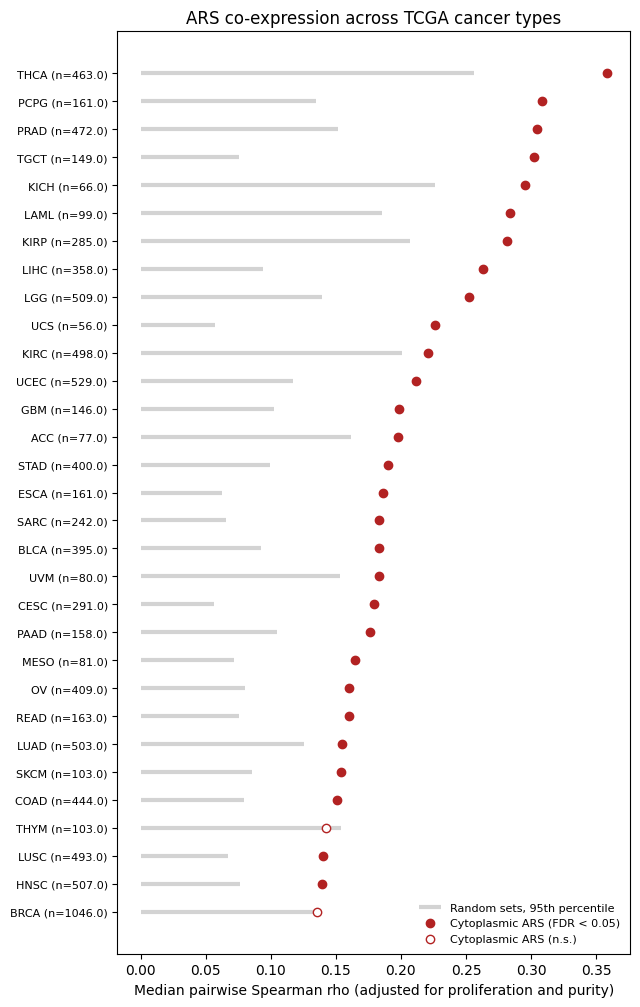

Question 1: co-expressed beyond random in 29 of 31 cancer types (FDR < 0.05)


In [17]:
# 14. FIGURE 3: adjusted ARS co-expression per cancer type vs random expectation
d = done.sort_values("ars_cyto_rho_adj")
y = np.arange(len(d))
sig_mask = (d["fdr_adj"] < 0.05).values

fig, ax = plt.subplots(figsize=(6.5, 0.28*len(d) + 1.5))
ax.hlines(y, 0, d["null95_adj"], color="lightgrey", lw=3, label="Random sets, 95th percentile")
ax.scatter(d["ars_cyto_rho_adj"][sig_mask], y[sig_mask], color="firebrick", zorder=3, label="Cytoplasmic ARS (FDR < 0.05)")
ax.scatter(d["ars_cyto_rho_adj"][~sig_mask], y[~sig_mask], facecolor="white", edgecolor="firebrick", zorder=3, label="Cytoplasmic ARS (n.s.)")
ax.set_yticks(y); ax.set_yticklabels([f"{p} (n={n})" for p, n in zip(d["project"], d["n_adjusted"])], fontsize=8)
ax.set_xlabel("Median pairwise Spearman rho (adjusted for proliferation and purity)")
ax.set_title("ARS co-expression across TCGA cancer types")
ax.legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout(); fig.savefig(FIG_DIR/"fig3_pancancer_coexpression.png", dpi=200); plt.show()

n_sig = int(sig_mask.sum())
print(f"Question 1: co-expressed beyond random in {n_sig} of {len(d)} cancer types (FDR < 0.05)")

## 15. Questions 2 and 3 — Is the ATF4 link specific?
For every cancer type we have four ATF4 correlations (one per module). The box plot shows their distribution across cancer types; each grey line connects the values of one cancer type.

**Paired Wilcoxon signed-rank test:** compares two modules *within the same cancer types*. It asks whether one module is consistently higher than the other, without assuming normally distributed values.

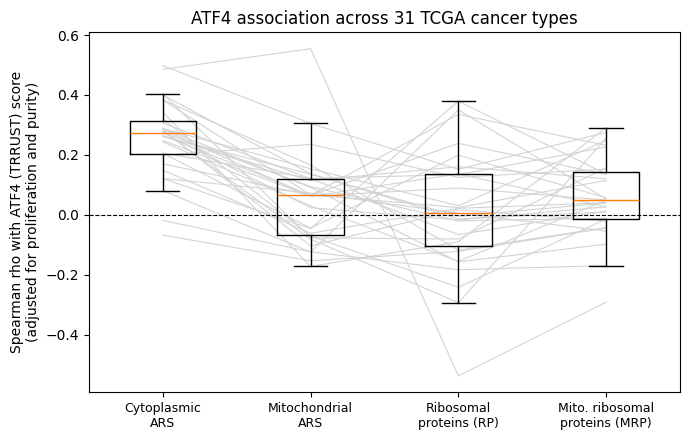

,test,median_difference,cancers_where_first_is_higher,wilcoxon_p
0,Q2: ARS_cyto vs ARS_mito,0.197,29/31,3.259629e-09
1,Q3: ARS_cyto vs RP,0.266,27/31,3.054738e-06
2,ATF4 link left beyond RP (median rho),0.288,29/31 positive,NaN
3,Sensitivity: ATF4 (UPR) vs ARS_cyto (median rho),0.678,31/31 positive,NaN


In [18]:
# 15. FIGURE 4: ATF4 association per module across cancer types
modules = ["atf4_ARS_cyto", "atf4_ARS_mito", "atf4_RP", "atf4_MRP"]
labels = ["Cytoplasmic\nARS", "Mitochondrial\nARS", "Ribosomal\nproteins (RP)", "Mito. ribosomal\nproteins (MRP)"]

fig, ax = plt.subplots(figsize=(7, 4.5))
for _, r in done.iterrows():
    ax.plot(range(4), r[modules].values.astype(float), color="lightgrey", lw=0.8, zorder=1)
ax.boxplot([done[m] for m in modules], positions=range(4), widths=0.45, showfliers=False, zorder=2)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xticks(range(4)); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Spearman rho with ATF4 (TRRUST) score\n(adjusted for proliferation and purity)")
ax.set_title(f"ATF4 association across {len(done)} TCGA cancer types")
fig.tight_layout(); fig.savefig(FIG_DIR/"fig4_atf4_specificity.png", dpi=200); plt.show()

tests = {
    "Q2: ARS_cyto vs ARS_mito": ("atf4_ARS_cyto", "atf4_ARS_mito"),
    "Q3: ARS_cyto vs RP":       ("atf4_ARS_cyto", "atf4_RP"),
}
rows = []
for name, (a, b) in tests.items():
    diff = done[a] - done[b]
    stat, p = wilcoxon(done[a], done[b], alternative="greater")
    rows.append({"test": name, "median_difference": round(float(diff.median()), 3),
                 "cancers_where_first_is_higher": f"{int((diff > 0).sum())}/{len(diff)}", "wilcoxon_p": float(p)})
rows.append({"test": "ATF4 link left beyond RP (median rho)", "median_difference": round(float(done['atf4_ARS_cyto_beyond_RP'].median()), 3),
             "cancers_where_first_is_higher": f"{int((done['atf4_ARS_cyto_beyond_RP'] > 0).sum())}/{len(done)} positive", "wilcoxon_p": np.nan})
rows.append({"test": "Sensitivity: ATF4 (UPR) vs ARS_cyto (median rho)", "median_difference": round(float(done['atf4upr_ARS_cyto'].median()), 3),
             "cancers_where_first_is_higher": f"{int((done['atf4upr_ARS_cyto'] > 0).sum())}/{len(done)} positive", "wilcoxon_p": np.nan})
specificity = pd.DataFrame(rows)
display(specificity)
specificity.to_csv(RES_DIR/"atf4_specificity_tests.tsv", sep="\t", index=False)

## 16. Summary table

In [19]:
# 16. SUMMARY TABLE
summary = pd.DataFrame([
    ["cancer_types_analysed", len(done)],
    ["cancer_types_excluded", int((results["status"] != "done").sum())],
    ["tumours_analysed_total", int(done["n_adjusted"].sum())],
    ["cancer_types_with_purity_adjustment", int(done["purity_used"].sum())],
    ["Q1_coexpressed_FDR<0.05", f"{n_sig}/{len(done)}"],
    ["median_ars_cyto_rho_adj", round(float(done["ars_cyto_rho_adj"].median()), 3)],
    ["median_atf4_ARS_cyto", round(float(done["atf4_ARS_cyto"].median()), 3)],
    ["median_atf4_ARS_mito", round(float(done["atf4_ARS_mito"].median()), 3)],
    ["median_atf4_RP", round(float(done["atf4_RP"].median()), 3)],
    ["Q2_wilcoxon_p_cyto_gt_mito", f"{specificity.loc[0, 'wilcoxon_p']:.2g}"],
    ["Q3_wilcoxon_p_cyto_gt_RP", f"{specificity.loc[1, 'wilcoxon_p']:.2g}"],
    ["median_atf4_ARS_cyto_beyond_RP", round(float(done["atf4_ARS_cyto_beyond_RP"].median()), 3)],
], columns=["metric", "value"])
display(summary)
summary.to_csv(RES_DIR/"step2_summary.tsv", sep="\t", index=False)

,metric,value
0,cancer_types_analysed,31
1,cancer_types_excluded,2
2,tumours_analysed_total,9447
3,cancer_types_with_purity_adjustment,31
4,Q1_coexpressed_FDR<0.05,29/31
5,median_ars_cyto_rho_adj,0.186
6,median_atf4_ARS_cyto,0.274
7,median_atf4_ARS_mito,0.065
8,median_atf4_RP,0.005
9,Q2_wilcoxon_p_cyto_gt_mito,3.3e-09


## 17. Decision rule (written before the results)

| Result | Interpretation | Next step |
| --- | --- | --- |
| **A.** Co-expressed (FDR < 0.05) in **at least two thirds** of cancer types **and** Q3 Wilcoxon p < 0.05 | ARS genes form a pan-cancer module whose ATF4 link goes beyond general translation | Main story: "ATF4-linked ARS module". Continue with Step 3 (differential expression) and Step 5 (chromatin) |
| **B.** Co-expressed in at least two thirds, but Q3 **not** significant | ARS genes behave like the rest of the translation machinery; ATF4 does not add specificity | Reframe: ARS as part of the translation programme; look for the cancer types where the ATF4 link *is* specific |
| **C.** Co-expressed in **fewer** than two thirds | The module is cancer-type specific | Focus the preprint on the cancer types where it exists and ask what distinguishes them |

All three outcomes lead to a preprint; they lead to different titles.

In [20]:
# 17. DECISION
share = n_sig / len(done)
q3_p = specificity.loc[1, "wilcoxon_p"]
if share >= 2/3 and q3_p < 0.05:
    decision = "A - Pan-cancer ARS module with an ATF4 link beyond general translation."
elif share >= 2/3:
    decision = "B - Pan-cancer module, but the ATF4 link is not specific beyond ribosomal proteins."
else:
    decision = "C - The ARS module is cancer-type specific."

print("STEP 2 DECISION:", decision)
print(f"Co-expressed in {n_sig}/{len(done)} cancer types ({share:.0%}); Q3 Wilcoxon p = {q3_p:.2g}")
_ = (RES_DIR/"step2_decision.txt").write_text(decision + "\n")

STEP 2 DECISION: A - Pan-cancer ARS module with an ATF4 link beyond general translation.
Co-expressed in 29/31 cancer types (94%); Q3 Wilcoxon p = 3.1e-06


## 18. Copying the outputs to Google Drive
Results, figures and logs are copied. The downloaded expression matrices were already deleted inside the loop.

In [21]:
# 18. PERMANENT STORAGE
EXPORT_DIR = Path("/content/drive/MyDrive/ARS_project/02_pancancer")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
for folder in (RES_DIR, FIG_DIR, LOG_DIR):
    shutil.copytree(folder, EXPORT_DIR/folder.name, dirs_exist_ok=True)
print("Outputs copied to:", EXPORT_DIR)

Outputs copied to: /content/drive/MyDrive/ARS_project/02_pancancer


## 19. What to report when something goes wrong

```text
Notebook version:
Step number of the failing cell:
Full error message:
Last step that ran successfully:
Output of Step 12 (the progress lines):
Content of results/excluded_projects.tsv:
```

## Limitations of this step
* TCGA tumours only; an independent cohort follows in Step 6.
* Correlation-based: an ATF4 link in expression data does not prove that ATF4 binds ARS promoters in tumours. Steps 5 (ATAC-seq, ATF4 ChIP-seq) address this.
* TRRUST targets come from the literature and are biased towards well-studied genes; the Hallmark UPR score is a second, independent check.
* Purity estimates are missing for some samples; those cancer types are adjusted for proliferation only (`purity_used = False`).

## References for this notebook
* Liberzon A. et al. (2015). The Molecular Signatures Database Hallmark Gene Set Collection. *Cell Systems* 1(6), 417–425.
* Han H. et al. (2018). TRRUST v2: an expanded reference database of human and mouse transcriptional regulatory interactions. *Nucleic Acids Research* 46(D1), D380–D386.
* Kuleshov M.V. et al. (2016). Enrichr: a comprehensive gene set enrichment analysis web server 2016 update. *Nucleic Acids Research* 44(W1), W90–W97.
* Fang Z. et al. (2023). GSEApy: a comprehensive package for performing gene set enrichment analysis in Python. *Bioinformatics* 39(1), btac757.
* Carter S.L. et al. (2012). Absolute quantification of somatic DNA alterations in human cancer. *Nature Biotechnology* 30, 413–421.
* Hoadley K.A. et al. (2018). Cell-of-origin patterns dominate the molecular classification of 10,000 tumors from 33 types of cancer. *Cell* 173(2), 291–304.